# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [21]:
df = pd.read_csv(r"C:\Users\vaish\Downloads\titanic.csv")

In [22]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [30]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 418
Columns: 12


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [32]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,29.399522,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,12.992298,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,25.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,36.375000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [33]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [34]:
df["Age"] = df.groupby("Pclass")["Age"].transform(
    lambda x: x.fillna(x.median())
)

In [35]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [36]:
df.drop("Cabin", axis=1, inplace=True)

In [37]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

In [38]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (418, 11)


In [40]:
df["FamilySize"] = (
    df["SibSp"] +
    df["Parch"] + 1
)

In [41]:
df["IsAlone"] = np.where(
    df["FamilySize"] == 1,
    "Yes",
    "No"
)

In [42]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=[
        "Child",
        "Teen",
        "Adult",
        "Middle Age",
        "Senior"
    ]
)

In [43]:
survival_rate = (
    df["Survived"].mean() * 100
)

print(
    f"Overall Survival Rate: {survival_rate:.2f}%"
)

Overall Survival Rate: 36.36%


In [44]:
df.groupby("Sex")["Survived"].mean()*100

Sex
female    100.0
male        0.0
Name: Survived, dtype: float64

In [45]:
df.groupby("Pclass")["Survived"].mean()*100

Pclass
1    46.728972
2    32.258065
3    33.027523
Name: Survived, dtype: float64

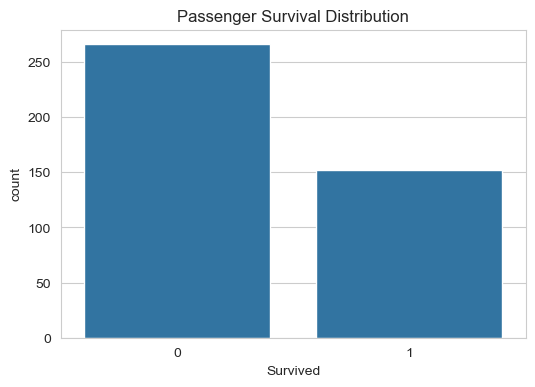

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Survived",
    data=df
)

plt.title(
    "Passenger Survival Distribution"
)

plt.show()

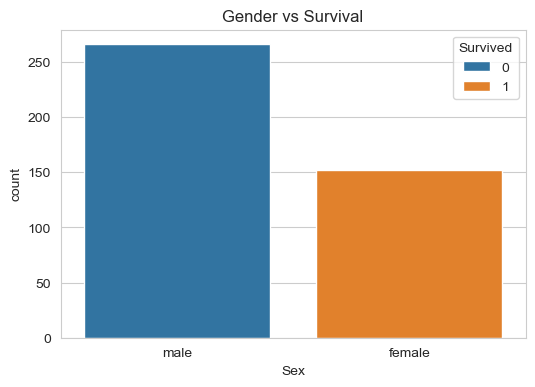

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title(
    "Gender vs Survival"
)

plt.show()

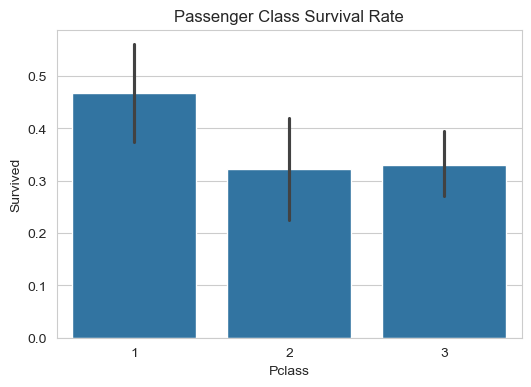

In [48]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=df
)

plt.title(
    "Passenger Class Survival Rate"
)

plt.show()

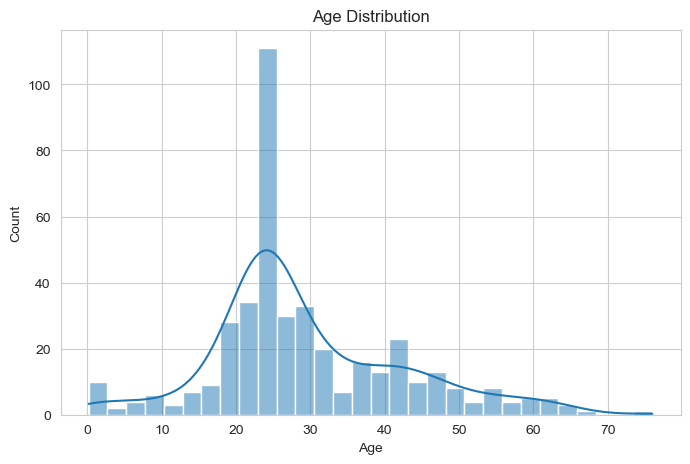

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title(
    "Age Distribution"
)

plt.show()